In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import re
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer 
from textblob import TextBlob

In [89]:
df=pd.read_csv("spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [90]:
df.shape

(5572, 2)

In [91]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [92]:
df.duplicated().any()

np.True_

In [93]:
df.drop_duplicates(inplace=True)

In [94]:
category_counts=df["Category"].value_counts()
category_counts


Category
ham     4516
spam     641
Name: count, dtype: int64

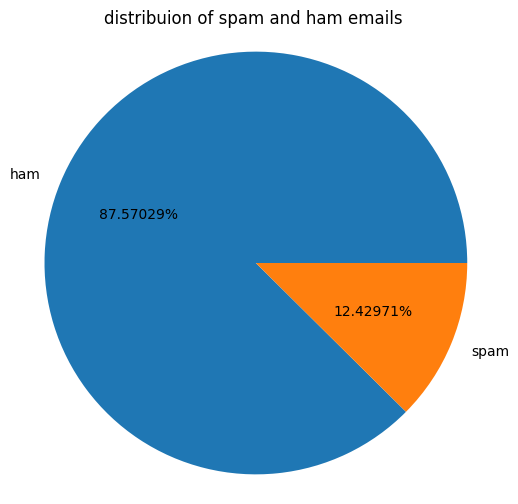

In [95]:
#plotting the graph of spam and ham emails

plt.figure(figsize=(6,6))
plt.pie(category_counts,labels=category_counts.index,autopct='%2.5f%%')
plt.title("distribuion of spam and ham emails ")
plt.axis("equal")
plt.show()

# Preprocessing step to make different df for diff category

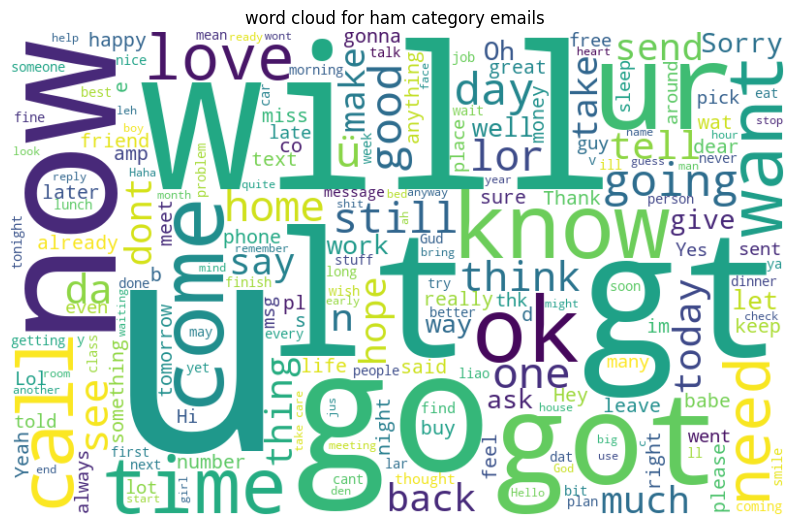

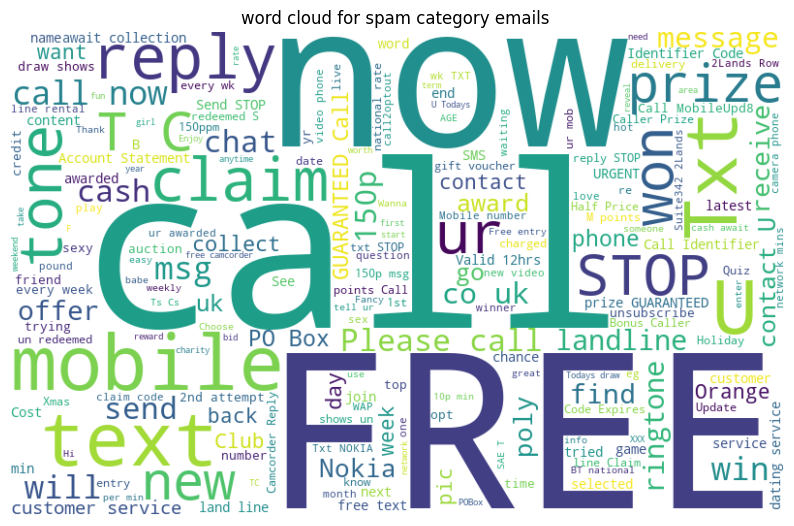

In [96]:
from wordcloud import WordCloud
for category in df["Category"].unique():
    filtered_category=df[df["Category"]==category]
    text=''.join(filtered_category["Message"])
    wordcloud=WordCloud(width=800,height=500,background_color='white').generate(text)
    
    plt.figure(figsize=(10,8))
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.title(f'word cloud for {category} category emails ')
    plt.axis('off')
    plt.show()
    

In [97]:
le=LabelEncoder()
df["Category"]=le.fit_transform(df["Category"])
df.head()


,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


#preprocessing step :
Preprocessing

¶
1. Lower Casing
2. Remove Extra White Spaces
3. Remove HTML Tags
4. Remove URLs
5. Remove Punctuations
6. Remove Special Characters
7. Remove Numeric Values
8. Remove Non-alpha Numeric
9. Handling ChatWords¶
10. Handling StopWords
11. Handling Emojis
12. Stemming

In [98]:
# Lower casing
df["Message"]=df["Message"].str.lower()
df.head()

,Category,Message
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [99]:
# Removing extra white spaces
df["Message"]=df["Message"].str.strip()
df.head()

,Category,Message
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [100]:
!pip install bs4


Defaulting to user installation because normal site-packages is not writeable


In [101]:
from bs4 import BeautifulSoup
def remove_html_tags(text):
    soup=BeautifulSoup(text,'html.parser')
    return soup.text
df["Message"]=df["Message"].apply(remove_html_tags)

C:\Users\DELL\AppData\Local\Temp\ipykernel_14988\2825811940.py:3: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup=BeautifulSoup(text,'html.parser')


In [102]:
df.head()

,Category,Message
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [103]:
def remove_url(text):
    return re.sub(r'http\S+|www\S+', '', text)

df["Message"]=df["Message"].apply(remove_url)

In [104]:
df.head()

,Category,Message
0,0,"go until jurong point, crazy.. available only ..."
1,0,ok lar... joking wif u oni...
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor... u c already then say...
4,0,"nah i don't think he goes to usf, he lives aro..."


In [105]:
from string import punctuation
punc=punctuation

def remove_punc(text):
    return text.translate(str.maketrans(' ',' ',punctuation))

df["Message"]=df["Message"].apply(remove_punc)

In [106]:
def remove_special_char(text):
    pattern = r'[^a-zA-Z0-9\s]'
    new_text=re.sub(pattern,'',text)
    return new_text
df["Message"]=df["Message"].apply(remove_special_char)

In [107]:
chat_words = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later","CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See","PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA?": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain", "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don't care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "BFF": "Best friends forever",
    "CSL": "Can't stop laughing"
}

In [108]:
def chat_words2(text):
    words=text.split()
    
    for i,word in enumerate(words):
        if word.lower() in chat_words:
            words[i]=chat_words[word].lower()
    return " ".join(words)

df["Message"]=df["Message"].apply(chat_words2)

In [109]:
df.head()

,Category,Message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...


In [110]:
#removing Stop words
import nltk
nltk.download("stopwords")

stop_words=set(stopwords.words('english'))

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


In [111]:
def remove_stopwords(text):
    text=text.split()
    filtered_text=[word for word in text if word not in stop_words]
    return " ".join(filtered_text)
df["Message"]=df["Message"].apply(remove_stopwords)

In [112]:
df.head()

,Category,Message
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say early hor u c already say
4,0,nah dont think goes usf lives around though


In [113]:
import emoji
def handle_emojis(text):
    return emoji.demojize(text)

df["Message"]=df["Message"].apply(handle_emojis)

In [114]:
#stemming- convert the verbs to their stem forms usind porter stemmer

porter_stemmer=PorterStemmer()

df["message_stemmed"]=df["Message"].apply(lambda x: ' '.join([porter_stemmer.stem(word) for word in x.split()]))

# Modelling - creating the vectors from text

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["Message"],
    df["Category"],
    test_size=0.2,
    random_state=40,
    stratify=df["Category"]  # VERY IMPORTANT
)

cv = CountVectorizer(stop_words='english')

x_train = cv.fit_transform(X_train_text)
x_test  = cv.transform(X_test_text)


In [117]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

multiNB = MultinomialNB()
multiNB.fit(x_train, y_train)

y_pred = multiNB.predict(x_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not spam", "spam"]
))


Confusion Matrix:
[[892  12]
 [ 14 114]]

Classification Report:
              precision    recall  f1-score   support

    Not spam       0.98      0.99      0.99       904
        spam       0.90      0.89      0.90       128

    accuracy                           0.97      1032
   macro avg       0.94      0.94      0.94      1032
weighted avg       0.97      0.97      0.97      1032



In [119]:
import joblib
joblib.dump(multiNB,"spam_detector_model.pkl")
joblib.dump(cv,"count_vectorizer.pkl")

['count_vectorizer.pkl']